# M8.0 — Regime validation (raw float)

Plan: [`plans/milestone_08/08_single_view_localization_plan.md`](../../plans/milestone_08/08_single_view_localization_plan.md).  
Primary narrative: [`GummyBearTomography_Final_Report.ipynb`](../../GummyBearTomography_Final_Report.ipynb) §4 (Excel → generate → catalog).  
Next: `08_2_encoder_proof_of_concept.ipynb`.

**Gap vs Final Report:** §4 covers generation and splits; this notebook restores **Milestone 8 Step 0E** evidence — absolute-intensity role panels and **low / medium / high** intensity histograms on float `.raw.tif` (not JPEG auto-contrast).

**Conclusion:** Background `μa` / `μs` are **nuisance factors**, not model inputs. Regime differences must be visible on raw float intensity.


In [1]:
from pathlib import Path
import shutil
import sys
import subprocess

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

# Concurrent notebook installs race on ./build (Errno 17 File exists).
for name in ("build", "dist"):
    shutil.rmtree(ROOT / name, ignore_errors=True)
for egg in (ROOT / "src").glob("*.egg-info"):
    shutil.rmtree(egg, ignore_errors=True)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        f"{ROOT}[dl,dev]",
        "-c",
        str(ROOT / "requirements.txt"),
    ]
)

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ROOT=.


In [2]:
from tomography_ml_validation.milestone_08 import m8_corpus_paths, describe_paths

# Prefer full multi-regime corpus when present; fall back to demo.
DATA_MODE = "full" if (ROOT / "data/generated/m8_1/single_particle").is_dir() else "demo"
paths = m8_corpus_paths(ROOT, data_mode=DATA_MODE)
print(f"DATA_MODE={DATA_MODE}")
print(describe_paths(paths))


DATA_MODE=full
workbook_path=configs/m8/localization_single_particle.xlsx  output_root=data/generated/m8_1/single_particle  cache_root=data/generated/m8_1/single_particle/_cache


In [3]:
from IPython.display import display
import matplotlib.pyplot as plt

from tomography_ml_validation.milestone_08 import (
    load_m8_catalog_rows,
    pick_regime_exemplars,
)
from gummybear_validation.milestone_08 import (
    plot_regime_intensity_histograms,
    plot_regime_role_grid,
)


## Exemplar sequences per optical regime

Pin a **matched particle index** across `opt_m8_{low,med,high}_001` (default `000001`) so the Δ hotspot is the same geometric placement under three background optics.

This notebook pins matched `*_000001` exemplars across regimes so Δ hotspots are comparable. Particle positions are workbook-deterministic.


In [4]:
rows = load_m8_catalog_rows(ROOT, data_mode=DATA_MODE)
# Matched particle across regimes (stable figure). Override particle_index or pass
# sequence_ids={"low": "...", "medium": "...", "high": "..."} to pin didactic examples.
exemplars = pick_regime_exemplars(rows, particle_index="000001")
assert list(exemplars) == ["low", "medium", "high"], list(exemplars)
assert set(exemplars) == {"low", "medium", "high"}, (
    f"Need all three regimes for Milestone 8 Step 0E panels; got {sorted(exemplars)}. "
    "Generate / restore data/generated/m8_1/single_particle or a multi-regime demo."
)
xyz0 = None
for label, row in exemplars.items():
    xyz = (row.particle_x, row.particle_y, row.particle_z)
    if xyz0 is None:
        xyz0 = xyz
    print(
        f"{label:8s}  {row.sequence_id}  status={row.field_status}  "
        f"setup={row.optical_setup_id}  mu_a={row.bear_mu_a}  mu_s={row.bear_mu_s}  "
        f"xyz=({row.particle_x:.2f},{row.particle_y:.2f},{row.particle_z:.2f})"
    )
assert all(
    abs(exemplars[k].particle_x - xyz0[0]) < 1e-9
    and abs(exemplars[k].particle_y - xyz0[1]) < 1e-9
    and abs(exemplars[k].particle_z - xyz0[2]) < 1e-9
    for k in exemplars
), "exemplars must share one particle centre across regimes"


low       bear_m8_low_000001  status=complete  setup=opt_m8_low_001  mu_a=0.003  mu_s=0.01  xyz=(5.85,6.25,-1.62)
medium    bear_m8_med_000001  status=complete  setup=opt_m8_med_001  mu_a=0.01  mu_s=0.03  xyz=(5.85,6.25,-1.62)
high      bear_m8_high_000001  status=complete  setup=opt_m8_high_001  mu_a=0.03  mu_s=0.1  xyz=(5.85,6.25,-1.62)


## Role grid + absolute intensity histograms

Shared colour scale across regimes so absolute intensity differences remain interpretable.

The Δ column is the projected particle perturbation for **this** matched centre at `frame_index=0` (camera angle from the schedule). Changing `particle_index` or `frame_index` moves the hotspot; regenerating the same `sequence_id` with the same workbook centres does not.


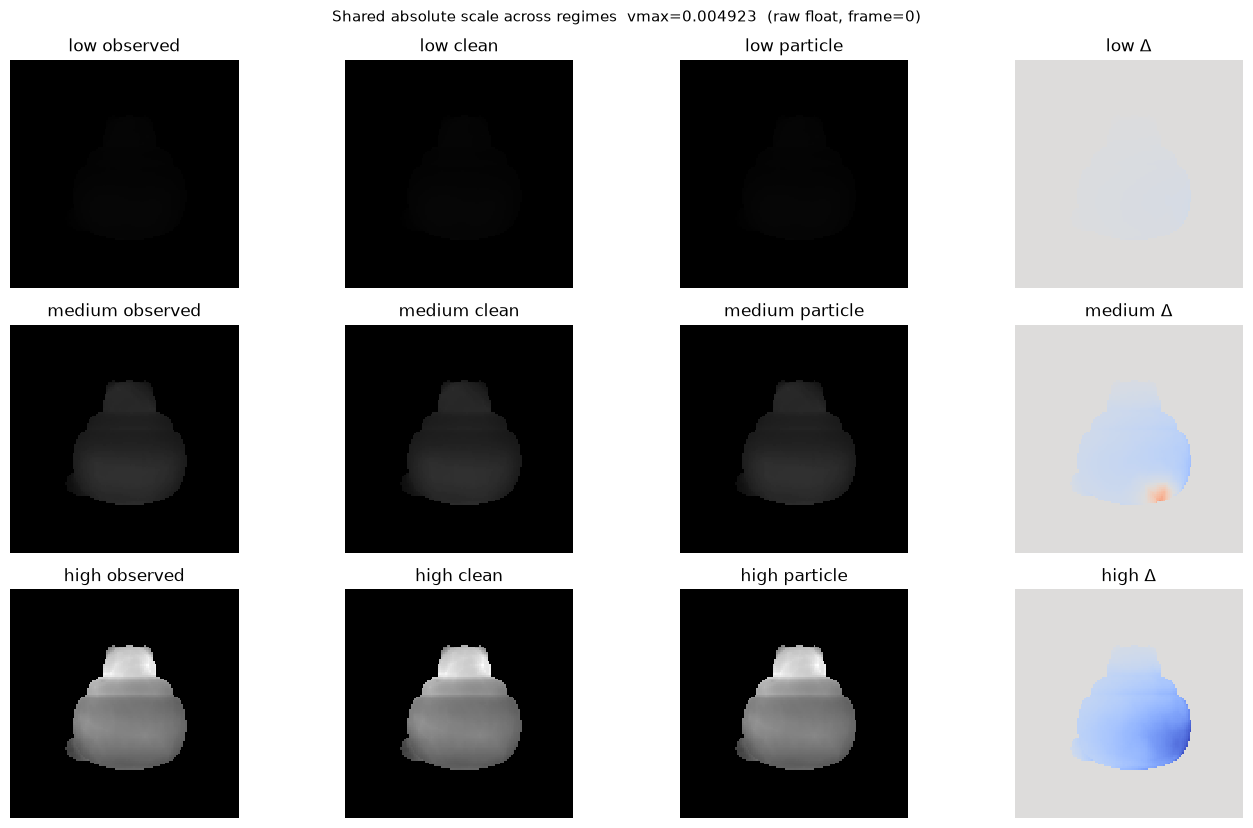

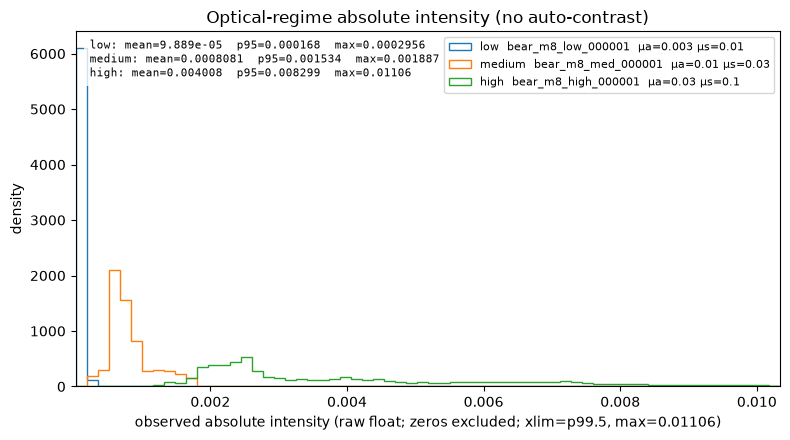

Milestone 8 Step 0E regime panels: regimes differ in absolute raw-float intensity.


In [5]:
fig_grid = plot_regime_role_grid(exemplars, frame_index=0)
plt.show()

fig_hist = plot_regime_intensity_histograms(exemplars, role="observed")
plt.show()
print("Milestone 8 Step 0E regime panels: regimes differ in absolute raw-float intensity.")
